============================================================
NOTEBOOK 04 — STATISTICAL CORRELATION + REGRESSION
Find statistically significant relationships in accident data
============================================================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

CLEAN = '../data/cleaned'
OUTPUT = '../outputs'

import os
os.makedirs(OUTPUT, exist_ok=True)
print("Imports OK")


Imports OK


In [2]:
state_master = pd.read_csv(f'{CLEAN}/state_master.csv')
latest = state_master[state_master['year'] == 2024].dropna(
    subset=['accidents','fatalities','fatality_rate_per_accident']
).copy()

# Remove tiny UTs (< 500 accidents) — they distort correlations with extreme rates
latest_filtered = latest[latest['accidents'] >= 500].copy()
print(f"States after filtering tiny UTs: {len(latest_filtered)}")
print(latest_filtered[['state','accidents','fatalities',
                        'fatality_rate_per_accident']].head(8))


States after filtering tiny UTs: 25
             state  accidents  fatalities  fatality_rate_per_accident
11  Andhra Pradesh    19557.0      8346.0                      0.4268
23           Assam     7848.0      3351.0                      0.4270
29           Bihar    11610.0      9347.0                      0.8051
41    Chhattisgarh    14857.0      6945.0                      0.4675
53           Delhi     5657.0      1551.0                      0.2742
59             Goa     2682.0       286.0                      0.1066
65         Gujarat    15588.0      7717.0                      0.4951
71         Haryana     9806.0      4689.0                      0.4782


In [3]:
# From state_master we have: accidents, fatalities, fatality_rate_per_accident
# Derive log transforms (handles skewness in accident counts)
latest_filtered['log_accidents']  = np.log(latest_filtered['accidents'])
latest_filtered['log_fatalities'] = np.log(latest_filtered['fatalities'])

# Accident share = this state's % of national accidents
total_accidents_2024 = latest_filtered['accidents'].sum()
latest_filtered['accident_share_pct'] = (
    latest_filtered['accidents'] / total_accidents_2024 * 100
).round(3)

# YoY changes already in state_master
latest_filtered['yoy_accident_change']  = latest_filtered['yoy_accident_change'].fillna(0)
latest_filtered['yoy_fatality_change']  = latest_filtered['yoy_fatality_change'].fillna(0)

# Percent YoY change
latest_filtered['yoy_acc_pct'] = (
    latest_filtered['yoy_accident_change'] / latest_filtered['accidents'] * 100
).round(3)
latest_filtered['yoy_fat_pct'] = (
    latest_filtered['yoy_fatality_change'] / latest_filtered['fatalities'] * 100
).round(3)

print("\nEngineered features added:")
print(latest_filtered[['state','log_accidents','accident_share_pct',
                        'yoy_acc_pct','yoy_fat_pct']].head())



Engineered features added:
             state  log_accidents  accident_share_pct  yoy_acc_pct  \
11  Andhra Pradesh       9.881089               4.026       -2.004   
23           Assam       8.968014               1.616        5.441   
29           Bihar       9.359622               2.390        5.134   
41    Chhattisgarh       9.606226               3.059        9.349   
53           Delhi       8.640649               1.165       -3.129   

    yoy_fat_pct  
11        2.504  
23        1.641  
29        5.071  
41       11.217  
53        6.061  


In [4]:
corr_cols = [
    'accidents',
    'fatalities',
    'fatality_rate_per_accident',
    'log_accidents',
    'log_fatalities',
    'yoy_acc_pct',
    'yoy_fat_pct',
    'accident_share_pct',
]
corr_matrix = latest_filtered[corr_cols].corr(method='pearson')

print("\nCorrelation Matrix (Pearson):")
print(corr_matrix.round(3).to_string())



Correlation Matrix (Pearson):
                            accidents  fatalities  fatality_rate_per_accident  log_accidents  log_fatalities  yoy_acc_pct  yoy_fat_pct  accident_share_pct
accidents                       1.000       0.816                      -0.278          0.865           0.696        0.159       -0.056               1.000
fatalities                      0.816       1.000                       0.128          0.809           0.839        0.175        0.010               0.816
fatality_rate_per_accident     -0.278       0.128                       1.000         -0.086           0.331       -0.049       -0.129              -0.278
log_accidents                   0.865       0.809                      -0.086          1.000           0.901        0.153        0.007               0.865
log_fatalities                  0.696       0.839                       0.331          0.901           1.000        0.134       -0.041               0.696
yoy_acc_pct                     0.159  

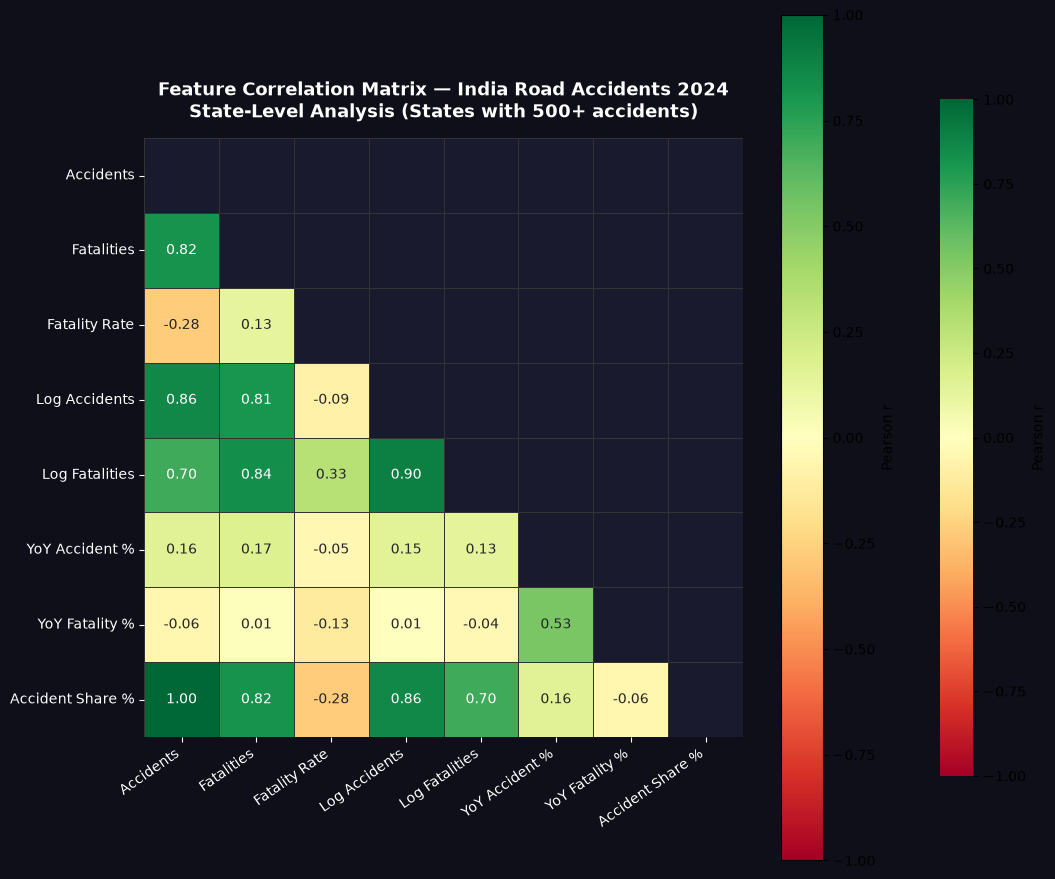

Correlation heatmap saved: outputs/correlation_heatmap.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

# Clean labels for display
clean_labels = [
    'Accidents', 'Fatalities', 'Fatality Rate',
    'Log Accidents', 'Log Fatalities',
    'YoY Accident %', 'YoY Fatality %',
    'Accident Share %'
]

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='#333',
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    xticklabels=clean_labels,
    yticklabels=clean_labels,
    ax=ax
)

ax.set_title(
    'Feature Correlation Matrix — India Road Accidents 2024\n'
    'State-Level Analysis (States with 500+ accidents)',
    color='white', fontsize=13, fontweight='bold', pad=15
)
ax.tick_params(colors='white', labelsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', color='white')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color='white')
plt.colorbar(ax.collections[0], ax=ax, label='Pearson r')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Correlation heatmap saved: outputs/correlation_heatmap.png")


In [6]:
# For each meaningful pair, print r, p-value, and interpretation
print("\n" + "="*60)
print("PAIRWISE CORRELATION SIGNIFICANCE TESTS")
print("="*60)

pairs = [
    ('accidents',   'fatalities',                'Do more accidents = more deaths?'),
    ('log_accidents','fatality_rate_per_accident','Does accident volume predict fatality rate?'),
    ('yoy_acc_pct', 'yoy_fat_pct',               'Do accident increases drive fatality increases?'),
    ('accident_share_pct','fatality_rate_per_accident','Do high-share states have worse rates?'),
]

results = []
for x_col, y_col, question in pairs:
    x = latest_filtered[x_col].dropna()
    y = latest_filtered[y_col].dropna()
    idx = x.index.intersection(y.index)
    x, y = x.loc[idx], y.loc[idx]

    r, p = sp_stats.pearsonr(x, y)
    sig = "✅ SIGNIFICANT" if p < 0.05 else "❌ NOT significant"
    strength = (
        "Very Strong" if abs(r) > 0.7 else
        "Strong"      if abs(r) > 0.5 else
        "Moderate"    if abs(r) > 0.3 else
        "Weak"
    )
    direction = "Positive" if r > 0 else "Negative"

    print(f"\nQ: {question}")
    print(f"   r = {r:.4f} | p = {p:.4f} | {sig}")
    print(f"   Interpretation: {direction} {strength} correlation")

    results.append({'x': x_col, 'y': y_col, 'r': round(r,4),
                    'p_value': round(p,4), 'significant': p < 0.05,
                    'strength': strength, 'question': question})

results_df = pd.DataFrame(results)
results_df.to_csv(f'{OUTPUT}/correlation_significance.csv', index=False)



PAIRWISE CORRELATION SIGNIFICANCE TESTS

Q: Do more accidents = more deaths?
   r = 0.8161 | p = 0.0000 | ✅ SIGNIFICANT
   Interpretation: Positive Very Strong correlation

Q: Does accident volume predict fatality rate?
   r = -0.0861 | p = 0.6823 | ❌ NOT significant
   Interpretation: Negative Weak correlation

Q: Do accident increases drive fatality increases?
   r = 0.5326 | p = 0.0061 | ✅ SIGNIFICANT
   Interpretation: Positive Strong correlation

Q: Do high-share states have worse rates?
   r = -0.2783 | p = 0.1780 | ❌ NOT significant
   Interpretation: Negative Weak correlation


In [7]:
print("\n" + "="*60)
print("OLS REGRESSION 1: Fatalities ~ Accidents (State Level 2024)")
print("="*60)

X1 = sm.add_constant(latest_filtered['accidents'])
y1 = latest_filtered['fatalities']
model1 = sm.OLS(y1, X1).fit()
print(model1.summary())

# Extract key numbers
coef  = model1.params['accidents']
r2    = model1.rsquared
p_acc = model1.pvalues['accidents']
print(f"\nKEY: For every 1 additional accident in a state,")
print(f"     fatalities increase by {coef:.4f} on average")
print(f"     R² = {r2:.4f} | p = {p_acc:.6f}")



OLS REGRESSION 1: Fatalities ~ Accidents (State Level 2024)
                            OLS Regression Results                            
Dep. Variable:             fatalities   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     45.86
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           6.59e-07
Time:                        16:15:56   Log-Likelihood:                -239.81
No. Observations:                  25   AIC:                             483.6
Df Residuals:                      23   BIC:                             486.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [8]:
print("\n" + "="*60)
print("OLS REGRESSION 2: National Fatalities ~ Year (Trend 2019-2024)")
print("="*60)

national = state_master.groupby('year').agg(
    fatalities=('fatalities','sum'),
    accidents=('accidents','sum')
).reset_index()

X2 = sm.add_constant(national['year'])
y2 = national['fatalities']
model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

annual_increase = model2.params['year']
r2_nat = model2.rsquared
print(f"\nKEY: India adds ~{int(annual_increase):,} fatalities per year on average")
print(f"     R² = {r2_nat:.4f} — trend explains {r2_nat*100:.1f}% of variance")



OLS REGRESSION 2: National Fatalities ~ Year (Trend 2019-2024)
                            OLS Regression Results                            
Dep. Variable:             fatalities   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     6.278
Date:                Sun, 21 Jun 2026   Prob (F-statistic):             0.0664
Time:                        16:15:57   Log-Likelihood:                -62.541
No. Observations:                   6   AIC:                             129.1
Df Residuals:                       4   BIC:                             128.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

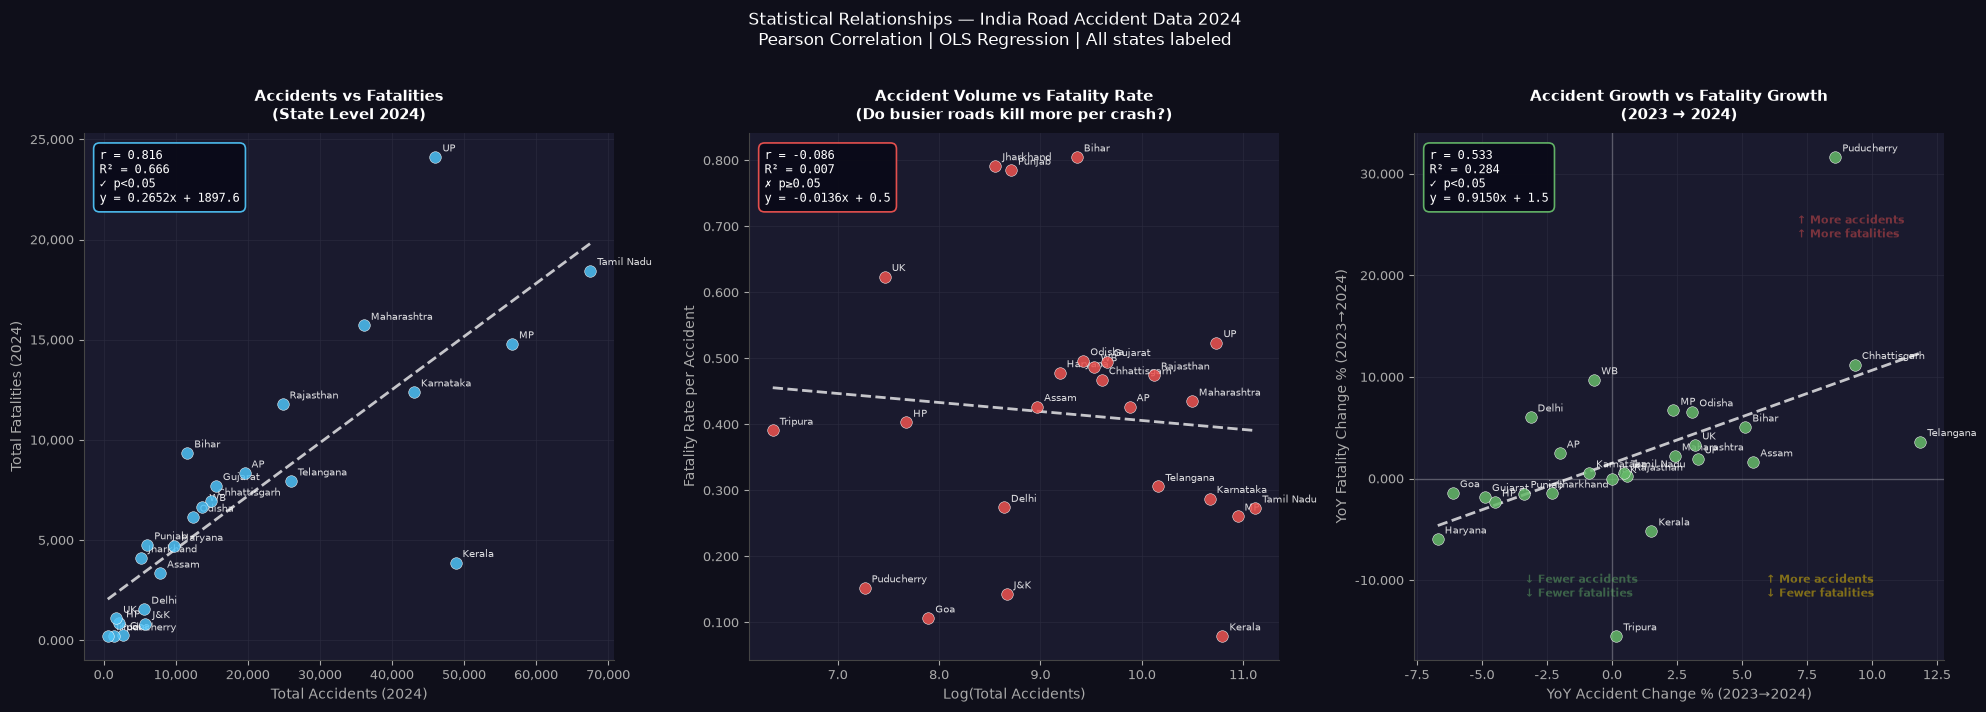

✅ Scatter plots saved — all states labeled + stats boxes + quadrant zones


In [9]:
# ============================================================
# 04_correlation_regression.ipynb — REPLACE CELL 9 (scatter plots) WITH THIS
# ============================================================
# Changes made:
# 1. ALL states labeled on scatter (not just top 5) with smart positioning
# 2. R² and p-value shown directly on chart as a text box
# 3. Regression equation shown on chart (y = mx + b)
# 4. Quadrant labels on YoY scatter (Improving/Worsening zones)
# 5. Axis values more readable (comma-formatted)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#0f0f1a')

def scatter_reg_qol(ax, x_data, y_data, labels, x_label, y_label,
                    title, color, quadrant_labels=False):
    ax.set_facecolor('#1a1a2e')

    slope, intercept, r, p, _ = sp_stats.linregress(x_data, y_data)

    # Scatter points
    ax.scatter(x_data, y_data, color=color, s=70, alpha=0.85,
               zorder=5, edgecolors='white', linewidths=0.4)

    # Regression line
    x_line = np.linspace(x_data.min(), x_data.max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color='white', linewidth=2, alpha=0.75, zorder=4,
            linestyle='--')

    # ✅ QOL: Label ALL states with smart nudge to reduce overlap
    x_arr = x_data.values
    y_arr = y_data.values
    lbl_arr = labels.values

    for i, (xi, yi, lbl) in enumerate(zip(x_arr, y_arr, lbl_arr)):
        # Short state name (abbreviate long names)
        short = (lbl.replace('Andaman & Nicobar Islands', 'A&N Islands')
                    .replace('D&N Haveli and Daman & Diu', 'D&NH')
                    .replace('Himachal Pradesh', 'HP')
                    .replace('Arunachal Pradesh', 'AR')
                    .replace('Jammu and Kashmir', 'J&K')
                    .replace('Madhya Pradesh', 'MP')
                    .replace('Uttar Pradesh', 'UP')
                    .replace('Andhra Pradesh', 'AP')
                    .replace('West Bengal', 'WB')
                    .replace('Uttarakhand', 'UK'))
        ax.annotate(
            short,
            (xi, yi),
            textcoords='offset points',
            xytext=(5, 4),
            fontsize=7,
            color='white',
            alpha=0.85,
        )

    # ✅ QOL: Stats box directly on chart
    sig_str = '✓ p<0.05' if p < 0.05 else '✗ p≥0.05'
    eq_str  = f'y = {slope:.4f}x + {intercept:.1f}'
    stats_txt = f'r = {r:.3f}\nR² = {r**2:.3f}\n{sig_str}\n{eq_str}'
    ax.text(0.03, 0.97, stats_txt,
            transform=ax.transAxes,
            color='white', fontsize=8.5,
            va='top', ha='left', family='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#0a0a18',
                      edgecolor=color, alpha=0.95, linewidth=1.2))

    # ✅ QOL: Quadrant labels for YoY scatter
    if quadrant_labels:
        xmid = 0
        ymid = 0
        ax.axvline(x=xmid, color='white', alpha=0.25, linewidth=1)
        ax.axhline(y=ymid, color='white', alpha=0.25, linewidth=1)
        qkw = dict(fontsize=8, alpha=0.45, fontweight='bold')
        ax.text(x_data.max()*0.6, y_data.max()*0.75,
                '↑ More accidents\n↑ More fatalities', color='#ef5350', **qkw)
        ax.text(x_data.min()*0.5, y_data.min()*0.75,
                '↓ Fewer accidents\n↓ Fewer fatalities', color='#66bb6a', **qkw)
        ax.text(x_data.max()*0.5, y_data.min()*0.75,
                '↑ More accidents\n↓ Fewer fatalities', color='#ffd600', **qkw)

    ax.set_title(title, color='white', fontsize=11,
                 fontweight='bold', pad=10)
    ax.set_xlabel(x_label, color='#aaa', fontsize=10)
    ax.set_ylabel(y_label, color='#aaa', fontsize=10)
    ax.tick_params(colors='#aaa', labelsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['bottom','left']].set_color('#444')
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{int(v):,}' if abs(v) > 100 else f'{v:.1f}'))
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{int(v):,}' if abs(v) > 100 else f'{v:.3f}'))
    ax.grid(color='#2a2a3e', alpha=0.8, linewidth=0.6)

# Chart 1: Accidents vs Fatalities
scatter_reg_qol(
    axes[0],
    latest_filtered['accidents'],
    latest_filtered['fatalities'],
    latest_filtered['state'],
    'Total Accidents (2024)',
    'Total Fatalities (2024)',
    'Accidents vs Fatalities\n(State Level 2024)',
    '#4fc3f7'
)

# Chart 2: Log Accidents vs Fatality Rate
scatter_reg_qol(
    axes[1],
    latest_filtered['log_accidents'],
    latest_filtered['fatality_rate_per_accident'],
    latest_filtered['state'],
    'Log(Total Accidents)',
    'Fatality Rate per Accident',
    'Accident Volume vs Fatality Rate\n(Do busier roads kill more per crash?)',
    '#ef5350'
)

# Chart 3: YoY % change scatter WITH quadrant labels
yoy_clean = latest_filtered[
    (latest_filtered['yoy_acc_pct'].abs() < 50) &
    (latest_filtered['yoy_fat_pct'].abs() < 50)
]
scatter_reg_qol(
    axes[2],
    yoy_clean['yoy_acc_pct'],
    yoy_clean['yoy_fat_pct'],
    yoy_clean['state'],
    'YoY Accident Change % (2023→2024)',
    'YoY Fatality Change % (2023→2024)',
    'Accident Growth vs Fatality Growth\n(2023 → 2024)',
    '#66bb6a',
    quadrant_labels=True
)

plt.suptitle(
    'Statistical Relationships — India Road Accident Data 2024\n'
    'Pearson Correlation | OLS Regression | All states labeled',
    color='white', fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/regression_scatter.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("✅ Scatter plots saved — all states labeled + stats boxes + quadrant zones")

In [10]:
print("\n" + "="*60)
print("SPEARMAN RANK CORRELATION (robust, non-parametric)")
print("="*60)

pairs_sp = [
    ('accidents', 'fatalities'),
    ('accidents', 'fatality_rate_per_accident'),
    ('yoy_acc_pct', 'yoy_fat_pct'),
]
for x_col, y_col in pairs_sp:
    x = latest_filtered[x_col].dropna()
    y = latest_filtered[y_col].dropna()
    idx = x.index.intersection(y.index)
    rho, p = sp_stats.spearmanr(x.loc[idx], y.loc[idx])
    print(f"{x_col} vs {y_col}: rho={rho:.4f}, p={p:.4f} "
          f"{'✅' if p<0.05 else '❌'}")



SPEARMAN RANK CORRELATION (robust, non-parametric)
accidents vs fatalities: rho=0.8700, p=0.0000 ✅
accidents vs fatality_rate_per_accident: rho=-0.1069, p=0.6110 ❌
yoy_acc_pct vs yoy_fat_pct: rho=0.6169, p=0.0010 ✅


In [11]:
print("\n" + "="*60)
print("SUMMARY — COPY THESE TO YOUR README")
print("="*60)
acc_fat_r, acc_fat_p = sp_stats.pearsonr(
    latest_filtered['accidents'], latest_filtered['fatalities'])
log_rate_r, log_rate_p = sp_stats.pearsonr(
    latest_filtered['log_accidents'],
    latest_filtered['fatality_rate_per_accident'])
yoy_r, yoy_p = sp_stats.pearsonr(
    yoy_clean['yoy_acc_pct'], yoy_clean['yoy_fat_pct'])

print(f"1. Accidents vs Fatalities: r={acc_fat_r:.3f}, p={acc_fat_p:.4f}")
print(f"   → {'Significant' if acc_fat_p<0.05 else 'Not significant'}")
print(f"2. Log(Accidents) vs Fatality Rate: r={log_rate_r:.3f}, p={log_rate_p:.4f}")
print(f"   → {'Significant' if log_rate_p<0.05 else 'Not significant'}")
print(f"3. YoY Accident % vs YoY Fatality %: r={yoy_r:.3f}, p={yoy_p:.4f}")
print(f"   → {'Significant' if yoy_p<0.05 else 'Not significant'}")
print(f"4. OLS: India adds ~{int(annual_increase):,} fatalities/year")
print(f"   National trend R²={r2_nat:.4f}")
print(f"5. OLS: Each additional state accident → {coef:.4f} more fatalities")



SUMMARY — COPY THESE TO YOUR README
1. Accidents vs Fatalities: r=0.816, p=0.0000
   → Significant
2. Log(Accidents) vs Fatality Rate: r=-0.086, p=0.6823
   → Not significant
3. YoY Accident % vs YoY Fatality %: r=0.533, p=0.0061
   → Significant
4. OLS: India adds ~5,971 fatalities/year
   National trend R²=0.6108
5. OLS: Each additional state accident → 0.2652 more fatalities
